---
# 1. Importando Bibliotecas

In [397]:
import pandas as pd
import scipy as scp
from scipy import optimize
from scipy.optimize import curve_fit
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

In [398]:
path_to_data = Path.cwd().parent / "Dados"
target = path_to_data / "Dados_USP.xlsx"

if not target.exists():
    raise SystemExit("Arquivo não encontrado")

df_raw = pd.read_excel(target,skiprows=1,sheet_name="Ajustes")
df_raw.head(2)

,Grupo,Nome,1km_23-abr,2km_16-abr,Pace 2km_16-abr,3km_21-abr,Pace 3km,1km pós 21km_z1_25-abr,% Piora do pace z1,1km_21-mai,...,Pace 42km,Volume 8 semanas (Km),Meta (Km),% realização dos treinos proposto,z1 (Km),z2 (Km),z3 (Km),%z1,%z2,%z3
0,1,S1,00:04:25,00:09:55,00:04:57.500000,00:15:27,00:05:09,00:05:03,0.143396,00:04:38,...,00:06:07.190000,406,408.0,99.509804,322,26,58,79.310345,6.403941,14.285714
1,1,S2,00:04:18,00:08:48,00:04:24,00:13:30,00:04:30,00:04:34,0.062016,00:04:09,...,00:05:20.095000,407,408.0,99.754902,323,26,58,79.361179,6.388206,14.250614


In [399]:
df = df_raw.copy()
df.columns

Index(['Grupo', 'Nome', '1km_23-abr', '2km_16-abr', 'Pace 2km_16-abr',
       '3km_21-abr', 'Pace 3km', '1km pós 21km_z1_25-abr',
       '% Piora do pace z1', '1km_21-mai', '21km_24-mai', 'Pace 21km',
       'Tempo dos 42km estimado com base no 21', 'Resultado da previsão',
       'Proporção entre tempo estimado e real', '1km pós 21km_TT_24-mai',
       '% Piora do pace TT', '42km', 'Pace 42km', 'Volume 8 semanas (Km)',
       'Meta (Km)', '% realização dos treinos proposto', 'z1 (Km)', 'z2 (Km)',
       'z3 (Km)', '%z1', '%z2', '%z3'],
      dtype='str')

In [400]:
for col, dtype in df.dtypes.items():
    if dtype == 'object':
        df.loc[:, col] = pd.to_timedelta(df[col].astype(str), errors="coerce")

---
# 2. Cluster

In [401]:
# 1. Defina o nome exato das colunas
col_tempo_real = "42km" 
col_tempo_estimado = "Tempo dos 42km estimado com base no 21"

# 2. Forçando a conversão para tempo (timedelta) ignorando textos inválidos
df[col_tempo_real] = pd.to_timedelta(df[col_tempo_real].astype(str), errors='coerce')
df[col_tempo_estimado] = pd.to_timedelta(df[col_tempo_estimado].astype(str), errors='coerce')

# 3. Agora extraímos os minutos com o .dt com segurança
df["tempo_42_real_min"] = df[col_tempo_real].dt.total_seconds() / 60
df["tempo_42_estimado_min"] = df[col_tempo_estimado].dt.total_seconds() / 60

# 4. Visualizando o resultado
df[["Nome", col_tempo_real, "tempo_42_real_min", col_tempo_estimado, "tempo_42_estimado_min"]].head()

,Nome,42km,tempo_42_real_min,Tempo dos 42km estimado com base no 21,tempo_42_estimado_min
0,S1,0 days 04:17:02,257.033333,0 days 04:03:32,243.533333
1,S2,0 days 03:44:04,224.066667,0 days 03:16:38,196.633333
2,S3,0 days 04:08:30,248.500000,0 days 03:54:42,234.700000
3,S4,0 days 03:00:28,180.466667,0 days 02:48:48,168.800000
4,S5,0 days 04:04:19,244.316667,0 days 03:42:18,222.300000


In [402]:
centros_clusters = {
    "A — 3h00 ± 10 min": 180,
    "B — 3h20 ± 10 min": 200,
    "C — 3h40 ± 10 min": 220,
    "D — 4h00 ± 10 min": 240,
    "E — 4h20 ± 10 min": 260
}

def classificar_cluster(tempo_real_min, tempo_estimado_min):
    if pd.isna(tempo_real_min):
        return np.nan

    centros = np.array(list(centros_clusters.values()))
    nomes = list(centros_clusters.keys())

    # Distância do tempo real até cada centro
    distancias_real = np.abs(centros - tempo_real_min)

    # Centro mais próximo usando o tempo real
    menor_distancia = distancias_real.min()
    candidatos = np.where(distancias_real == menor_distancia)[0]

    # Caso normal: há apenas um cluster mais próximo
    if len(candidatos) == 1:
        return nomes[candidatos[0]]

    # Caso de fronteira: por exemplo, exatamente 3h10, 3h30 etc.
    if not pd.isna(tempo_estimado_min):
        distancias_estimado = np.abs(centros[candidatos] - tempo_estimado_min)
        vencedor = candidatos[np.argmin(distancias_estimado)]
        return nomes[vencedor]

    # Caso não exista estimativa: escolhe o cluster mais rápido
    return nomes[candidatos[0]]

In [403]:
df["cluster_42km"] = df.apply(
    lambda linha: classificar_cluster(
        linha["tempo_42_real_min"],
        linha["tempo_42_estimado_min"]
    ),
    axis=1
)

# Tabela organizada pelo tempo real
df[["Nome", "Grupo", col_tempo_real, col_tempo_estimado, "tempo_42_real_min", "cluster_42km"]].sort_values("tempo_42_real_min").head(15)

,Nome,Grupo,42km,Tempo dos 42km estimado com base no 21,tempo_42_real_min,cluster_42km
12,S13,1,0 days 02:56:58,0 days 02:39:46,176.966667,A — 3h00 ± 10 min
13,S14,1,0 days 02:58:12,0 days 02:47:42,178.200000,A — 3h00 ± 10 min
3,S4,1,0 days 03:00:28,0 days 02:48:48,180.466667,A — 3h00 ± 10 min
9,S10,1,0 days 03:03:43,0 days 02:56:18,183.716667,A — 3h00 ± 10 min
22,P8,2,0 days 03:07:38,0 days 02:52:50,187.633333,A — 3h00 ± 10 min
10,S11,1,0 days 03:08:41,0 days 02:59:30,188.683333,A — 3h00 ± 10 min
24,P10,2,0 days 03:10:29,0 days 02:59:10,190.483333,B — 3h20 ± 10 min
8,S9,1,0 days 03:10:38,0 days 03:02:40,190.633333,B — 3h20 ± 10 min
6,S7,1,0 days 03:15:29,0 days 02:59:32,195.483333,B — 3h20 ± 10 min
14,S15,1,0 days 03:25:45,0 days 03:15:44,205.750000,B — 3h20 ± 10 min


In [404]:
df["cluster_42km"] = df.apply(
    lambda linha: classificar_cluster(
        linha["tempo_42_real_min"],
        linha["tempo_42_estimado_min"]
    ),
    axis=1
)

# Tabela organizada pelo tempo real
df[["Nome", "Grupo", col_tempo_real, col_tempo_estimado, "tempo_42_real_min", "cluster_42km"]].sort_values("tempo_42_real_min").head(15)

,Nome,Grupo,42km,Tempo dos 42km estimado com base no 21,tempo_42_real_min,cluster_42km
12,S13,1,0 days 02:56:58,0 days 02:39:46,176.966667,A — 3h00 ± 10 min
13,S14,1,0 days 02:58:12,0 days 02:47:42,178.200000,A — 3h00 ± 10 min
3,S4,1,0 days 03:00:28,0 days 02:48:48,180.466667,A — 3h00 ± 10 min
9,S10,1,0 days 03:03:43,0 days 02:56:18,183.716667,A — 3h00 ± 10 min
22,P8,2,0 days 03:07:38,0 days 02:52:50,187.633333,A — 3h00 ± 10 min
10,S11,1,0 days 03:08:41,0 days 02:59:30,188.683333,A — 3h00 ± 10 min
24,P10,2,0 days 03:10:29,0 days 02:59:10,190.483333,B — 3h20 ± 10 min
8,S9,1,0 days 03:10:38,0 days 03:02:40,190.633333,B — 3h20 ± 10 min
6,S7,1,0 days 03:15:29,0 days 02:59:32,195.483333,B — 3h20 ± 10 min
14,S15,1,0 days 03:25:45,0 days 03:15:44,205.750000,B — 3h20 ± 10 min


In [405]:
# Contagem de corredores por Cluster
print("Contagem de alunos por cluster:")
display(df["cluster_42km"].value_counts(dropna=False))

# Verificando se alguém fugiu muito da faixa de tempo esperada
fora_da_faixa = df[
    (df["tempo_42_real_min"] < 170) |
    (df["tempo_42_real_min"] > 270)
]

print("\nCorredores muito fora da faixa:")
display(fora_da_faixa[["Nome", col_tempo_real, "tempo_42_real_min", "cluster_42km"]])

Contagem de alunos por cluster:


cluster_42km
E — 4h20 ± 10 min    7
C — 3h40 ± 10 min    7
A — 3h00 ± 10 min    6
B — 3h20 ± 10 min    5
D — 4h00 ± 10 min    4
Name: count, dtype: int64


Corredores muito fora da faixa:


,Nome,42km,tempo_42_real_min,cluster_42km


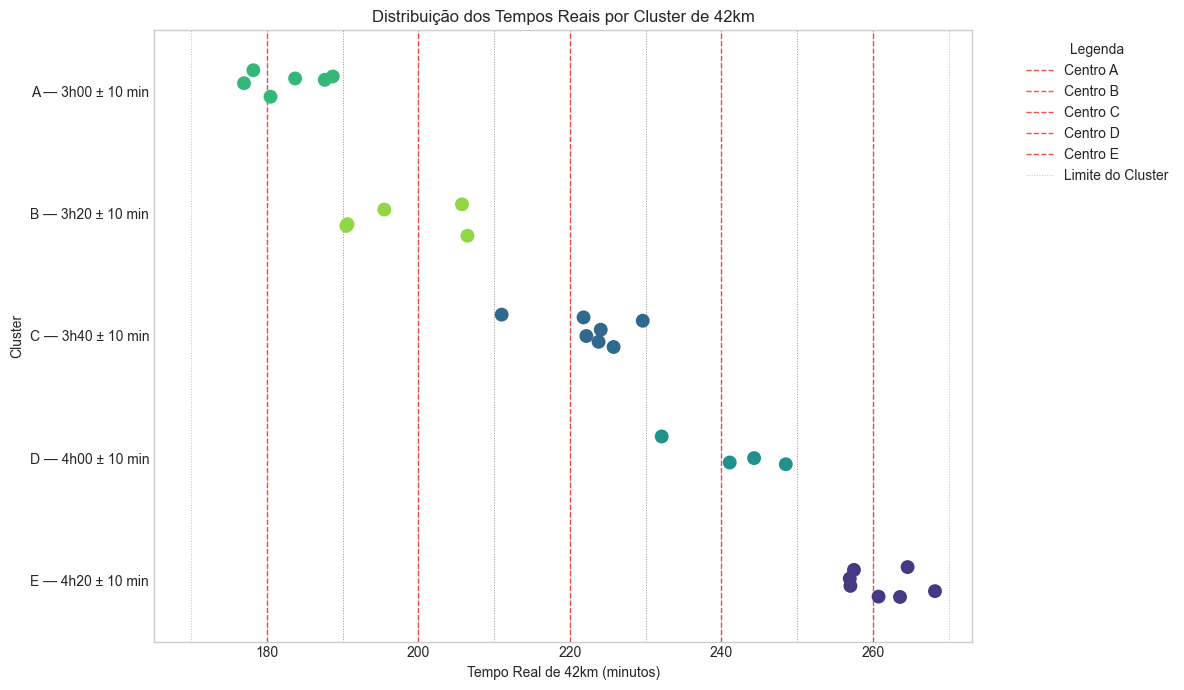

In [406]:
# Organizando os clusters para manter a ordem cronológica no gráfico
cluster_order = list(centros_clusters.keys())

plt.figure(figsize=(12, 7))
sns.stripplot(
    data=df,
    x="tempo_42_real_min",
    y="cluster_42km",
    order=cluster_order, # Set the order of clusters on y-axis
    jitter=0.2,
    hue="cluster_42km", # Color points by cluster
    palette="viridis",
    s=10,
    legend=False 
)

# Adicionando as linhas verticais para demarcar os limites e centros
legend_handles = []
legend_labels = []

for cluster_name, center_min in centros_clusters.items():
    # Linha principal do centro
    line_center = plt.axvline(center_min, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    # Limites das faixas (±10 min)
    line_bound_minus = plt.axvline(center_min - 10, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    line_bound_plus = plt.axvline(center_min + 10, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)

    # Montando a legenda sem duplicar entradas
    nome_legend = f'Centro {cluster_name.split("—")[0].strip()}'
    if nome_legend not in legend_labels:
        legend_handles.append(line_center)
        legend_labels.append(nome_legend)

# Inserindo um marcador geral para a linha de limite na legenda
if 'Limite do Cluster' not in legend_labels:
    legend_handles.append(line_bound_minus) 
    legend_labels.append('Limite do Cluster')

plt.title('Distribuição dos Tempos Reais por Cluster de 42km')
plt.xlabel('Tempo Real de 42km (minutos)')
plt.ylabel('Cluster')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(legend_handles, legend_labels, title='Legenda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
# 3. Fit dos dados aos modelos

## 3.1 Importação das bibliotecas

In [407]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from modelos import modelo_sigmoide, modelo_potencia, modelo_hyper

## 3.2 Criação do dataframe responsável pela fittagem

In [408]:
atleta_idx = np.random.choice(np.arange(0,stop=df.shape[0]-1,step=1),size=n_atletas) # De 0 a df.shape[0] - 1

In [409]:
dados_atleta = df.loc[
    :,
    ~df.columns.str.contains(
        r"Grupo|Nome|%|Pace|Tempo|pós|Resul|Volume|Meta|z|tempo|cluster",
        regex=True
    )
]


dados_atleta_x = dados_atleta.loc[:, ~dados_atleta.columns.str.contains(r"42km")]
dados_atleta_y = dados_atleta["42km"]

---
## 3.3 Criação das variáveis de fittagem (Tempo e Velocidade)

In [410]:
# Dicionário de distâncias em Km
colunas_distancia = {
    '1km_23-abr': 1.0,
    '2km_16-abr': 2.0,
    '3km_21-abr': 3.0,
    '1km_21-mai': 1.0,
    '21km_24-mai': 21.097,
    #'42km': 42.195
}


def getFittingData(df_raw:pd.DataFrame, idx_atleta:int) -> (list[float],list[float]):
    tempos_totais = []
    velocidades_totais = []

    df = df_raw.loc[idx_atleta,:]

    for col, dist in colunas_distancia.items():
        if pd.notna(df[col]) : 
            
            segundos = df[col].total_seconds()
            
            if segundos > 0: 
                minutos = segundos / 60
                horas = minutos / 60
                velocidade = dist / horas # Km/h
                
                tempos_totais.append(horas)
                velocidades_totais.append(velocidade)

    T_data = np.array(tempos_totais)
    V_data = np.array(velocidades_totais)

    return T_data,V_data



In [411]:
def fit_models(T_data:list[float], V_data:list[float], parametros_globais:pd.DataFrame,row: int = 0) -> (pd.DataFrame):
    # Chutes iniciais para T em Horas e V em Km/h
    p0_sig = [5.0, 2.0, 1.5, 9.0]
    p0_pow = [12.0, 0.93]
    p0_hyper = [1.0, -0.5, 0.5]

    parametros_globais.loc[row,"Grupo"] = df['Grupo'].iloc[row].astype(str)
    parametros_globais.loc[row,"Nome"] = df['Nome'].iloc[row]

    # --- Fit Modelo Potência ---
    try:
        popt_pow, _ = optimize.curve_fit(modelo_potencia, T_data, V_data, p0=p0_pow, maxfev=10000)
        parametros_globais.loc[row,'Potencia_S'] = popt_pow[0]
        parametros_globais.loc[row,'Potencia_E'] = popt_pow[1]
    except Exception as e:
        print(f"Erro no fit Potência: {e}")

    # --- Fit Modelo Sigmóide ---
    try:
        bounds_sig = ([0, -10, 0, 0], [30, 10, 10, np.max(V_data) * 1.05])
        popt_sig, _ = optimize.curve_fit(modelo_sigmoide, T_data, V_data, p0=p0_sig, maxfev=10000, bounds=bounds_sig)
        parametros_globais.loc[row,'Sigm_A'] = popt_sig[0]
        parametros_globais.loc[row,'Sigm_k'] = popt_sig[1] 
        parametros_globais.loc[row,'Sigm_t0'] = popt_sig[2] 
        parametros_globais.loc[row,'Sigm_Vbase'] = popt_sig[3]

    except Exception as e:
        print(f"Erro no fit Sigmóide: {e}")

    ## --- Fit Modelo Hiperbólico ---
    try:
        bounds_hyper = ([0, -10, 0.001], [np.max(V_data)*1.1, 10, 24])
        popt_hyper, _ = optimize.curve_fit(modelo_hyper, T_data, V_data, p0=p0_hyper, maxfev=10000, bounds=bounds_hyper)
        parametros_globais.loc[row,'Hyper_a'] = popt_hyper[0] 
        parametros_globais.loc[row,'Hyper_alpha'] = popt_hyper[1] 
        parametros_globais.loc[row,'Hyper_gamma'] = popt_hyper[2]

    except Exception as e:
        print(f"Erro no fit Hyper: {e}")

    return parametros_globais

In [412]:
plt.style.use('seaborn-v0_8-whitegrid')

In [413]:
param_results = pd.DataFrame()

for i in range(dados_atleta_x.shape[0]):
    T_data,V_data = getFittingData(dados_atleta_x,idx_atleta=i)

    param_results = fit_models(T_data=T_data,V_data=V_data,parametros_globais=param_results,row=i)

In [414]:
param_results.head(2)

,Grupo,Nome,Potencia_S,Potencia_E,Sigm_A,Sigm_k,Sigm_t0,Sigm_Vbase,Hyper_a,Hyper_alpha,Hyper_gamma
0,1,S1,10.761603,0.923858,7.574309,6.863954,1.574076e-16,10.415371,14.943396,0.329871,21.065247
1,1,S2,12.946774,0.968202,3.887307,9.416505,1.264370e-11,12.882876,14.036788,0.850892,24.000000


In [415]:
Ts = np.linspace(0.001,6) # 6h

plt.plot(Ts, modelo_hyper(Ts,*popt_hyper),label="Hyper")
plt.plot(Ts, modelo_potencia(Ts,*popt_pow),label="Potência")
plt.plot(Ts, modelo_sigmoide(Ts,*popt_sig),label="Sigmoide")

tempo_42km = dados_atleta_y.iloc[0].total_seconds() / 3600

plt.scatter(tempo_42km, 42/tempo_42km,label="42km Real")
plt.scatter(T_data,V_data,label="Dados Reais", marker="^",color="black")

plt.legend()
plt.title(f"Pessoa {atleta_idx}")
plt.tight_layout()

NameError: name 'popt_hyper' is not defined

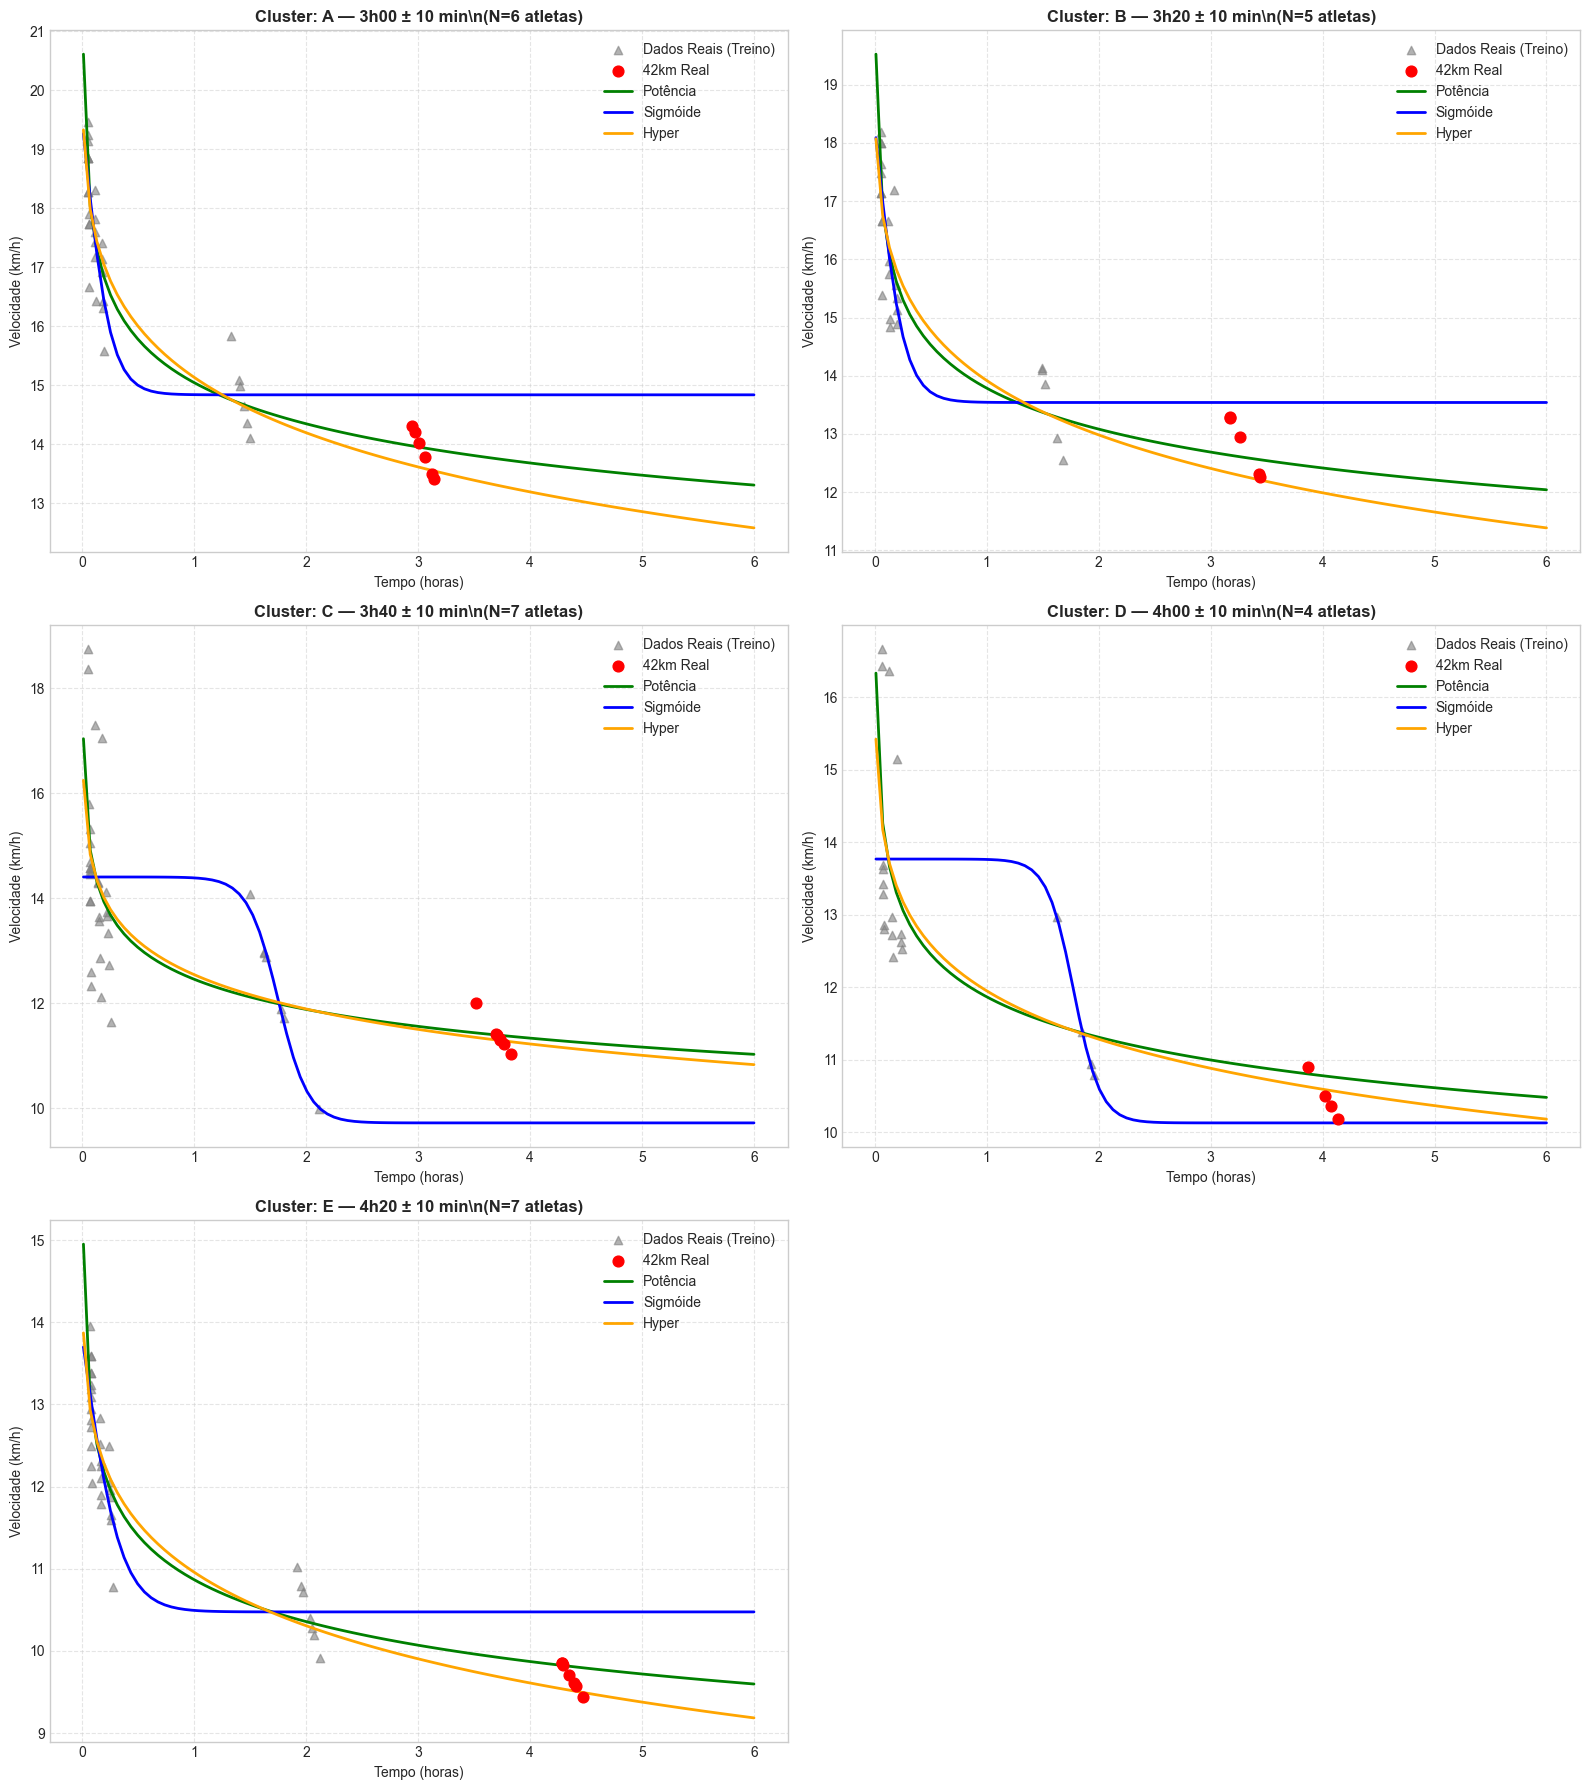

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from modelos import modelo_sigmoide, modelo_potencia, modelo_hyper

# 1. Identificar e organizar os clusters únicos
clusters_unicos = df['cluster_42km'].dropna().unique()
clusters_unicos = sorted(clusters_unicos) # Ordena alfabeticamente (A, B, C...)
n_clusters = len(clusters_unicos)

# 2. Configurar o grid do matplotlib (2 colunas, N linhas dependendo da qtde de clusters)
cols = 2
rows = math.ceil(n_clusters / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten()

# Dicionário APENAS para os dados de treino (excluímos os 42km do fit)
colunas_treino = {
    '1km_23-abr': 1.0,
    '2km_16-abr': 2.0,
    '3km_21-abr': 3.0,
    '1km_21-mai': 1.0,
    '21km_24-mai': 21.097
}

# Chutes iniciais estabelecidos (Escala: Horas e Km/h)
p0_sig = [5.0, 2.0, 1.5, 9.0]
p0_pow = [12.0, 0.93]
p0_hyper = [15.0, -0.5, 0.5]

# 3. Iterar sobre cada cluster e gerar o respectivo gráfico
for i, cluster in enumerate(clusters_unicos):
    ax = axes[i]
    df_cluster = df[df['cluster_42km'] == cluster]
    
    tempos_treino = []
    velocidades_treino = []
    tempos_42 = []
    velocidades_42 = []
    
    # Extrair todos os dados de todos os atletas do cluster atual
    for _, row in df_cluster.iterrows():
        # Dados de Treinamento
        for col, dist in colunas_treino.items():
            if pd.notna(row[col]) and row[col].total_seconds() > 0:
                h = row[col].total_seconds() / 3600
                tempos_treino.append(h)
                velocidades_treino.append(dist / h)
                
        # Dado de Validação (42km Real)
        if pd.notna(row['42km']) and row['42km'].total_seconds() > 0:
            h_42 = row['42km'].total_seconds() / 3600
            tempos_42.append(h_42)
            velocidades_42.append(42.195 / h_42)

    T_data = np.array(tempos_treino)
    V_data = np.array(velocidades_treino)
    
    if len(T_data) == 0:
        ax.set_title(f"{cluster}\\n(Sem dados suficientes)")
        continue

    # Plotar os pontos reais (Nuvem de dispersão do cluster)
    ax.scatter(T_data, V_data, label="Dados Reais (Treino)", marker="^", color="gray", alpha=0.6)
    if tempos_42:
        ax.scatter(tempos_42, velocidades_42, label="42km Real", marker="o", color="red", zorder=5, s=60)

    # Eixo X para desenhar a linha contínua dos modelos (de 0.01h até 6h)
    Ts = np.linspace(0.01, 6, 100)

    # --- Fit Lei de Potência ---
    try:
        popt_pow, _ = optimize.curve_fit(modelo_potencia, T_data, V_data, p0=p0_pow, maxfev=10000)
        ax.plot(Ts, modelo_potencia(Ts, *popt_pow), label="Potência", color="green", linewidth=2)
    except Exception:
        pass

    # --- Fit Sigmóide ---
    try:
        bounds_sig = ([0, -10, 0, 0], [30, 10, 10, np.max(V_data) * 1.05])
        popt_sig, _ = optimize.curve_fit(modelo_sigmoide, T_data, V_data, p0=p0_sig, maxfev=10000, bounds=bounds_sig)
        ax.plot(Ts, modelo_sigmoide(Ts, *popt_sig), label="Sigmóide", color="blue", linewidth=2)
    except Exception:
        pass

    # --- Fit Hiperbólico ---
    try:
        bounds_hyper = ([0, -10, 0.001], [np.max(V_data) * 1.1, 10, 24])
        popt_hyper, _ = optimize.curve_fit(modelo_hyper, T_data, V_data, p0=p0_hyper, maxfev=10000, bounds=bounds_hyper)
        ax.plot(Ts, modelo_hyper(Ts, *popt_hyper), label="Hyper", color="orange", linewidth=2)
    except Exception:
        pass

    # Formatação do subplot
    ax.set_title(f"Cluster: {cluster}\\n(N={len(df_cluster)} atletas)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Tempo (horas)")
    ax.set_ylabel("Velocidade (km/h)")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

# 4. Limpar eixos sobressalentes (caso o número de clusters seja ímpar)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


plt.show()

In [ ]:
# 1. Gerando os valores preditos por cada modelo
v_pred_sig = modelo_sigmoide(T_data, *popt_sig)
v_pred_pow = modelo_potencia(T_data, *popt_pow)
v_pred_hyper = modelo_hyper(T_data, a=popt_hyper[0], alpha=popt_hyper[1], gamma=popt_hyper[2])

# 2. Cálculo dos resíduos (diferença entre o real e o predito)
erro_sig = V_data - v_pred_sig
erro_pow = V_data - v_pred_pow
erro_hyper = V_data - v_pred_hyper

# 3. Norma Padrão (Norma L2 ou Euclidiana)
norma_sig = np.linalg.norm(erro_sig)
norma_pow = np.linalg.norm(erro_pow)
norma_hyper = np.linalg.norm(erro_hyper)

# 4. Soma dos Quadrados Totais (SST) para o R²
# Representa a variância total dos dados em relação à média
sst = np.sum((V_data - np.mean(V_data))**2)

# 5. Cálculo do R² (1 - SSR/SST)
# Onde SSR é a Soma dos Quadrados dos Resíduos (sum of squared residuals)
r2_sig = 1 - (np.sum(erro_sig**2) / sst)
r2_pow = 1 - (np.sum(erro_pow**2) / sst)
r2_hyper = 1 - (np.sum(erro_hyper**2) / sst)

# 6. Cálculo do RMSE (Root Mean Squared Error)
# Representa o erro médio absoluto na mesma unidade da variável dependente (ex: Km/min)
n = len(V_data)
rmse_sig = np.sqrt(np.sum(erro_sig**2) / n)
rmse_pow = np.sqrt(np.sum(erro_pow**2) / n)
rmse_hyper = np.sqrt(np.sum(erro_hyper**2) / n)

# 7. Exibição comparativa dos resultados
print("=== Comparativo de Erros dos Modelos ===")
print(f"Sigmóide    | R²: {r2_sig:.4f} | RMSE: {rmse_sig:.4f} | Norma L2: {norma_sig:.4f}")
print(f"Potência    | R²: {r2_pow:.4f} | RMSE: {rmse_pow:.4f} | Norma L2: {norma_pow:.4f}")
print(f"Hyper       | R²: {r2_hyper:.4f} | RMSE: {rmse_hyper:.4f} | Norma L2: {norma_hyper:.4f}")

=== Comparativo de Erros dos Modelos ===
Sigmóide    | R²: 0.8395 | RMSE: 0.4239 | Norma L2: 2.5078
Potência    | R²: 0.8310 | RMSE: 0.4350 | Norma L2: 2.5734
Hyper       | R²: 0.8006 | RMSE: 0.4724 | Norma L2: 2.7948


In [ ]:
print("--- Parâmetros Fitados ---")

# Sigmóide: [Amplitude (A), k, t0, V_base]
print(f"Sigmóide:")
print(f"  Amplitude de queda: {popt_sig[0]:.3f} km/h")
print(f"  Taxa de decaimento (k): {popt_sig[1]:.5f}")
print(f"  Ponto de inflexão (t0): {popt_sig[2]:.1f} s")
print(f"  Velocidade Base (Assíntota): {popt_sig[3]:.3f} km/h\n")

# Lei de Potência (Riegel): [S, E]
print(f"Lei de Potência:")
print(f"  Velocidade Limite (S): {popt_pow[0]:.3f} km/h")
print(f"  Fator de Endurance (E): {popt_pow[1]:.4f}\n")

# Hyper: [a, alpha, gamma]
print(f"Hyper:")
print(f"  Velocidade Máxima (a): {popt_hyper[0]:.3f} km/h")
print(f"  Decaimento (alpha): {popt_hyper[1]:.4f}")
print(f"  Fator de escala (gamma): {popt_hyper[2]:.1f}")

--- Parâmetros Fitados ---
Sigmóide:
  Amplitude de queda: 6.644 km/h
  Taxa de decaimento (k): 5.89600
  Ponto de inflexão (t0): 0.0 s
  Velocidade Base (Assíntota): 10.475 km/h

Lei de Potência:
  Velocidade Limite (S): 10.866 km/h
  Fator de Endurance (E): 0.9307

Hyper:
  Velocidade Máxima (a): 15.349 km/h
  Decaimento (alpha): 0.2876
  Fator de escala (gamma): 24.0
